<a href="https://colab.research.google.com/github/gmauricio-toledo/NLP-LCC/blob/main/Notebooks/09-Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Topic Detection</h1>

<h2>Topic Modeling</h1>

En esta notebook ahondaremos un poco más en la tarea de *Topic Modeling*. Para esto usamos varias técnicas:

* Clustering en representaciones vectoriales de documentos, ya sea BOW/TFIDF o embeddings.
* Latent Dirichlet Allocation (LDA). Implementación en [gensim](https://radimrehurek.com/gensim/models/ldamodel.html).
* Latent semantic analysis (LSA). Implementación en [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).

Además, evaluaremos estas tareas usando métricas propias de la tarea.
* [Coherence](https://radimrehurek.com/gensim/models/coherencemodel.html): [source](https://svn.aksw.org/papers/2015/WSDM_Topic_Evaluation/public.pdf)

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD

import spacy

from gensim import models, corpora
from gensim.models.coherencemodel import CoherenceModel

nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

# El corpus

Consideraremos un corpus de 92579 documentos de texto, consisten en noticias de CNN. **Origen desconocido**

In [5]:
!gdown 1S-KYaCpb39vMphrkdnceXUkUhzHeapt7

Downloading...
From (original): https://drive.google.com/uc?id=1S-KYaCpb39vMphrkdnceXUkUhzHeapt7
From (redirected): https://drive.google.com/uc?id=1S-KYaCpb39vMphrkdnceXUkUhzHeapt7&confirm=t&uuid=8b662214-2094-40fd-baeb-24dac493d6bf
To: /content/cnn_articles.txt
100% 365M/365M [00:04<00:00, 77.4MB/s]


In [6]:
with open('cnn_articles.txt', 'r', encoding='utf8') as f:
    articles = f.read().split('@delimiter')

print(len(articles))

cnn_df = pd.DataFrame({'document':articles})
cnn_df

92579


,document
0,-- Children in war-ravaged Afghanistan are sa...
1,"\n -- The Hard Rock Cafe franchise, famed for ..."
2,\nAn estimated 7 million people died due to ai...
3,\n -- A federal judge has temporarily blocked ...
4,"\n -- ""Terrorism and violence cannot be permis..."
...,...
92574,\n -- Pakistan's president has summoned the lo...
92575,\n -- The leader of one of the labs linked to ...
92576,\n -- The president of Florida A&M University ...
92577,"\nThis week, we mark the tenth anniversary of ..."


Nos quedamos solamente con los primeros 10000 artículos.

In [7]:
corpus = articles[:10000]

Exploremos los documentos, aquí podemos ver algunas palabras que podemos añadir a la lista de stopwords.

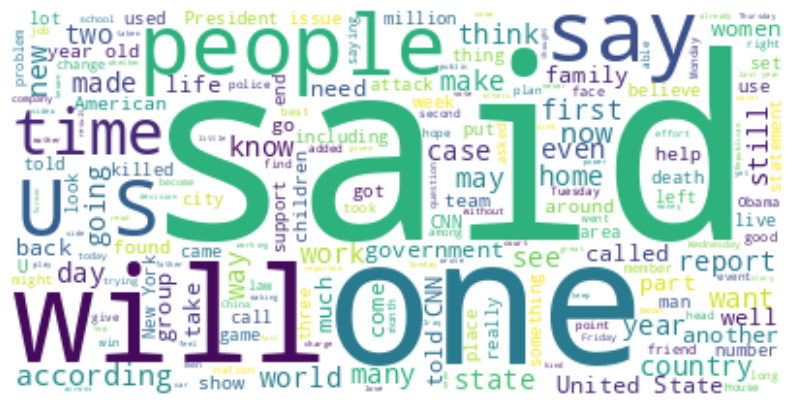

In [8]:
from wordcloud import WordCloud

wc = WordCloud(background_color="white", max_words=2000, contour_width=3, contour_color='steelblue')
wordcloud = wc.generate(" ".join(corpus))

plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

Hacemos el preprocesamiento usando un pipeline *ligero* de scipy. Tarda alrededor de 40s.

Recordar que también lo podemos hacer con nltk.

In [9]:
%%time

nlp = spacy.blank('en')

tokenized_docs = [[t.text for t in tok_doc if
          not t.is_punct and \
          not t.is_space and \
          t.is_alpha] for tok_doc in nlp.pipe(corpus) ]

CPU times: user 50 s, sys: 315 ms, total: 50.3 s
Wall time: 56.1 s


En la nube de palabras vemos que *said* es una palabra muy común y que, en cuestión de definir tópicos, puede no ser tan informativa. La agregamos a la lista de stopwords.

In [10]:
stopwords = nltk.corpus.stopwords.words('english')
stopwords.extend(['said'])

In [11]:
tokenized_docs = [[w for w in doc if w not in stopwords] for doc in tokenized_docs]

In [16]:
print(f"Artículo original:\n{articles[0][:102]}\n{70*'='}")
print(f"Artículo limpio y tokenizado:\n{tokenized_docs[0][:10]}")

Artículo original:
 -- Children in war-ravaged Afghanistan are safer than those growing up in London or New York, NATO's 
Artículo limpio y tokenizado:
['Children', 'war', 'ravaged', 'Afghanistan', 'safer', 'growing', 'London', 'New', 'York', 'NATO']


🛑 Si usamos un pipeline más completo podemos tardar hasta 15 minutos.

In [17]:
# %%time

# nlp = spacy.load("en_core_web_sm", disable=["ner"])

# tokenized_docs = [[t.text for t in tok_doc if
#           not t.is_punct and \
#           not t.is_space and \
#           t.is_alpha] for tok_doc in nlp.pipe(corpus) ]

# LSA con scikit-learn

Latent semantic analysis (LSA) is a technique in NLP, in particular distributional semantics, of analyzing relationships between a set of documents and the terms they contain by producing a set of concepts related to the documents and terms.

La idea es factorizar la matriz BOW usando Truncated SVD para obtener proyecciones de documentos y palabras en un espacio latente.

In [1]:
from IPython.display import HTML
HTML('<iframe width="600" height="547" frameborder="0" loading="lazy" allow="autoplay; fullscreen; picture-in-picture; clipboard-write; web-share" allowfullscreen src="https://commons.wikimedia.org/wiki/File:Topic_model_scheme.webm?embedplayer=true"></iframe>')


/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## TruncatedSVD

In [20]:
docs = [" ".join(doc) for doc in tokenized_docs] # Cada documento es una string

vectorizer = TfidfVectorizer(stop_words='english',
                            max_features= 1100,
                            smooth_idf=True)

X = vectorizer.fit_transform(docs)

X.shape

(10000, 1100)

In [21]:
svd_model = TruncatedSVD(n_components=10, # Número de tópicos que queremos encontrar
                         algorithm='randomized',
                         n_iter=100,
                         random_state=122)

svd_model.fit(X)
len(svd_model.components_)

10

Cuando aplicamos SVD a una matriz BOW **X** (documentos × palabras), la descomposición es:

**X ≈ U · Σ · Vᵀ**


* `components_` → Vᵀ (tópicos × palabras)

    Cada **fila** es un tópico latente, y los valores indican cuánto "pesa" cada palabra en ese tópico.
    ```python
    components_.shape = (n_components, n_palabras)
    ```

    - Valores altos positivos → palabras muy asociadas al tópico
    - Valores cercanos a 0 → palabras irrelevantes para ese tópico
    - Las palabras con mayor peso absoluto "definen" el tema

    **Ejemplo:** Si el tópico 3 tiene pesos altos en "python", "función", "código" → es un tópico de programación.


* `transform(X)` → U · Σ (documentos × tópicos)

    Cada **fila** es un documento representado en el espacio de tópicos.
    ```python
    transform(X).shape = (n_documentos, n_components)
    ```

    - Cada columna corresponde a un tópico
    - El valor indica qué tan fuerte está ese tópico en el documento
    - Documento con valor alto en columna 3 → el tópico 3 es relevante para ese doc

Se obtienen como:

| Variable | Corresponde a | Dimensiones |
|---|---|---|
| `transform(X)` | U · Σ | documentos × tópicos |
| `components_` | Vᵀ | tópicos × palabras |


* `components_` dice **qué es cada tópico** (en términos de palabras)
* `transform()` dice **cuánto de cada tópico hay en cada documento**.

### Exploremos los tópicos

In [22]:
svd_model.components_.shape

(10, 1100)

In [27]:
# Obtiene el vocabulario del vectorizer como array (cada índice corresponde a una columna de la matriz BOW)
terms = vectorizer.get_feature_names_out()

# Itera sobre cada tópico (fila de components_), i es el número de tópico, comp es el vector de pesos
for i, comp in enumerate(svd_model.components_):
    # Empareja cada palabra con su peso en este tópico → lista de tuplas (palabra, peso)
    terms_comp = zip(terms, comp)
    # Ordena por peso descendente y se queda con las 10 palabras más representativas del tópico
    sorted_terms = sorted(terms_comp, key= lambda x:x[1], reverse=True)[:10]
    print(f"Topic {str(i)}: ")
    # Imprime solo el nombre de la palabra (t[0]) de cada tupla
    for t in sorted_terms:
        print(t[0],end=',')
    print('\n'+75*'=')

Topic 0: 
people,police,new,year,cnn,time,world,says,like,told,
Topic 1: 
police,al,government,military,security,state,president,killed,obama,officials,
Topic 2: 
police,authorities,family,officer,county,death,told,officers,attorney,man,
Topic 3: 
league,al,cup,win,match,team,season,club,champions,second,
Topic 4: 
obama,court,police,president,republican,republicans,senate,democrats,house,party,
Topic 5: 
al,iraq,syria,isis,women,syrian,qaeda,iraqi,children,life,
Topic 6: 
police,obama,officers,president,people,city,house,romney,republicans,night,
Topic 7: 
police,china,women,chinese,korea,world,party,country,south,government,
Topic 8: 
korea,north,south,korean,nuclear,children,family,iran,obama,mother,
Topic 9: 
health,women,children,disease,care,hospital,patients,medical,people,school,


### ¿Qué tópicos hay en cada documento?

In [29]:
svd_model.transform(X).shape

(10000, 10)

Obtenemos los tópicos para cada documento

In [31]:
labels = np.argmax(svd_model.transform(X), axis=1)
labels

array([0, 0, 9, ..., 0, 4, 0])

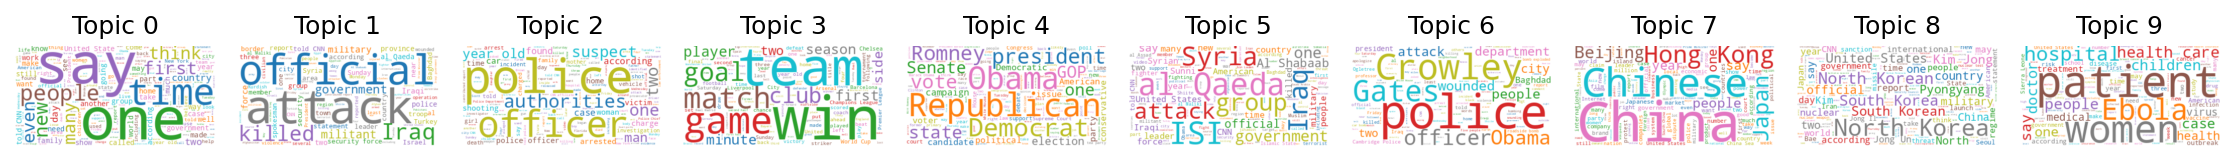

In [34]:
topics = np.argmax(svd_model.transform(X), axis=1)
num_topics = len(np.unique(topics))

docs_idxs_per_topic = [np.where(topics == i)[0] for i in range(num_topics)]

fig, axs = plt.subplots(1, num_topics, figsize=(15, 15),dpi=150)
for ax,j in zip(axs.flatten(),range(num_topics)):
    topic_docs = " ".join([docs[i] for i in docs_idxs_per_topic[j]])
    wc = WordCloud(background_color="white",
                   colormap='tab10',
                   max_words=2000).generate(topic_docs)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Topic {j}")
    ax.axis("off")
fig.tight_layout()
fig.show()

Comparemos con las palabras más importantes en cada tópico

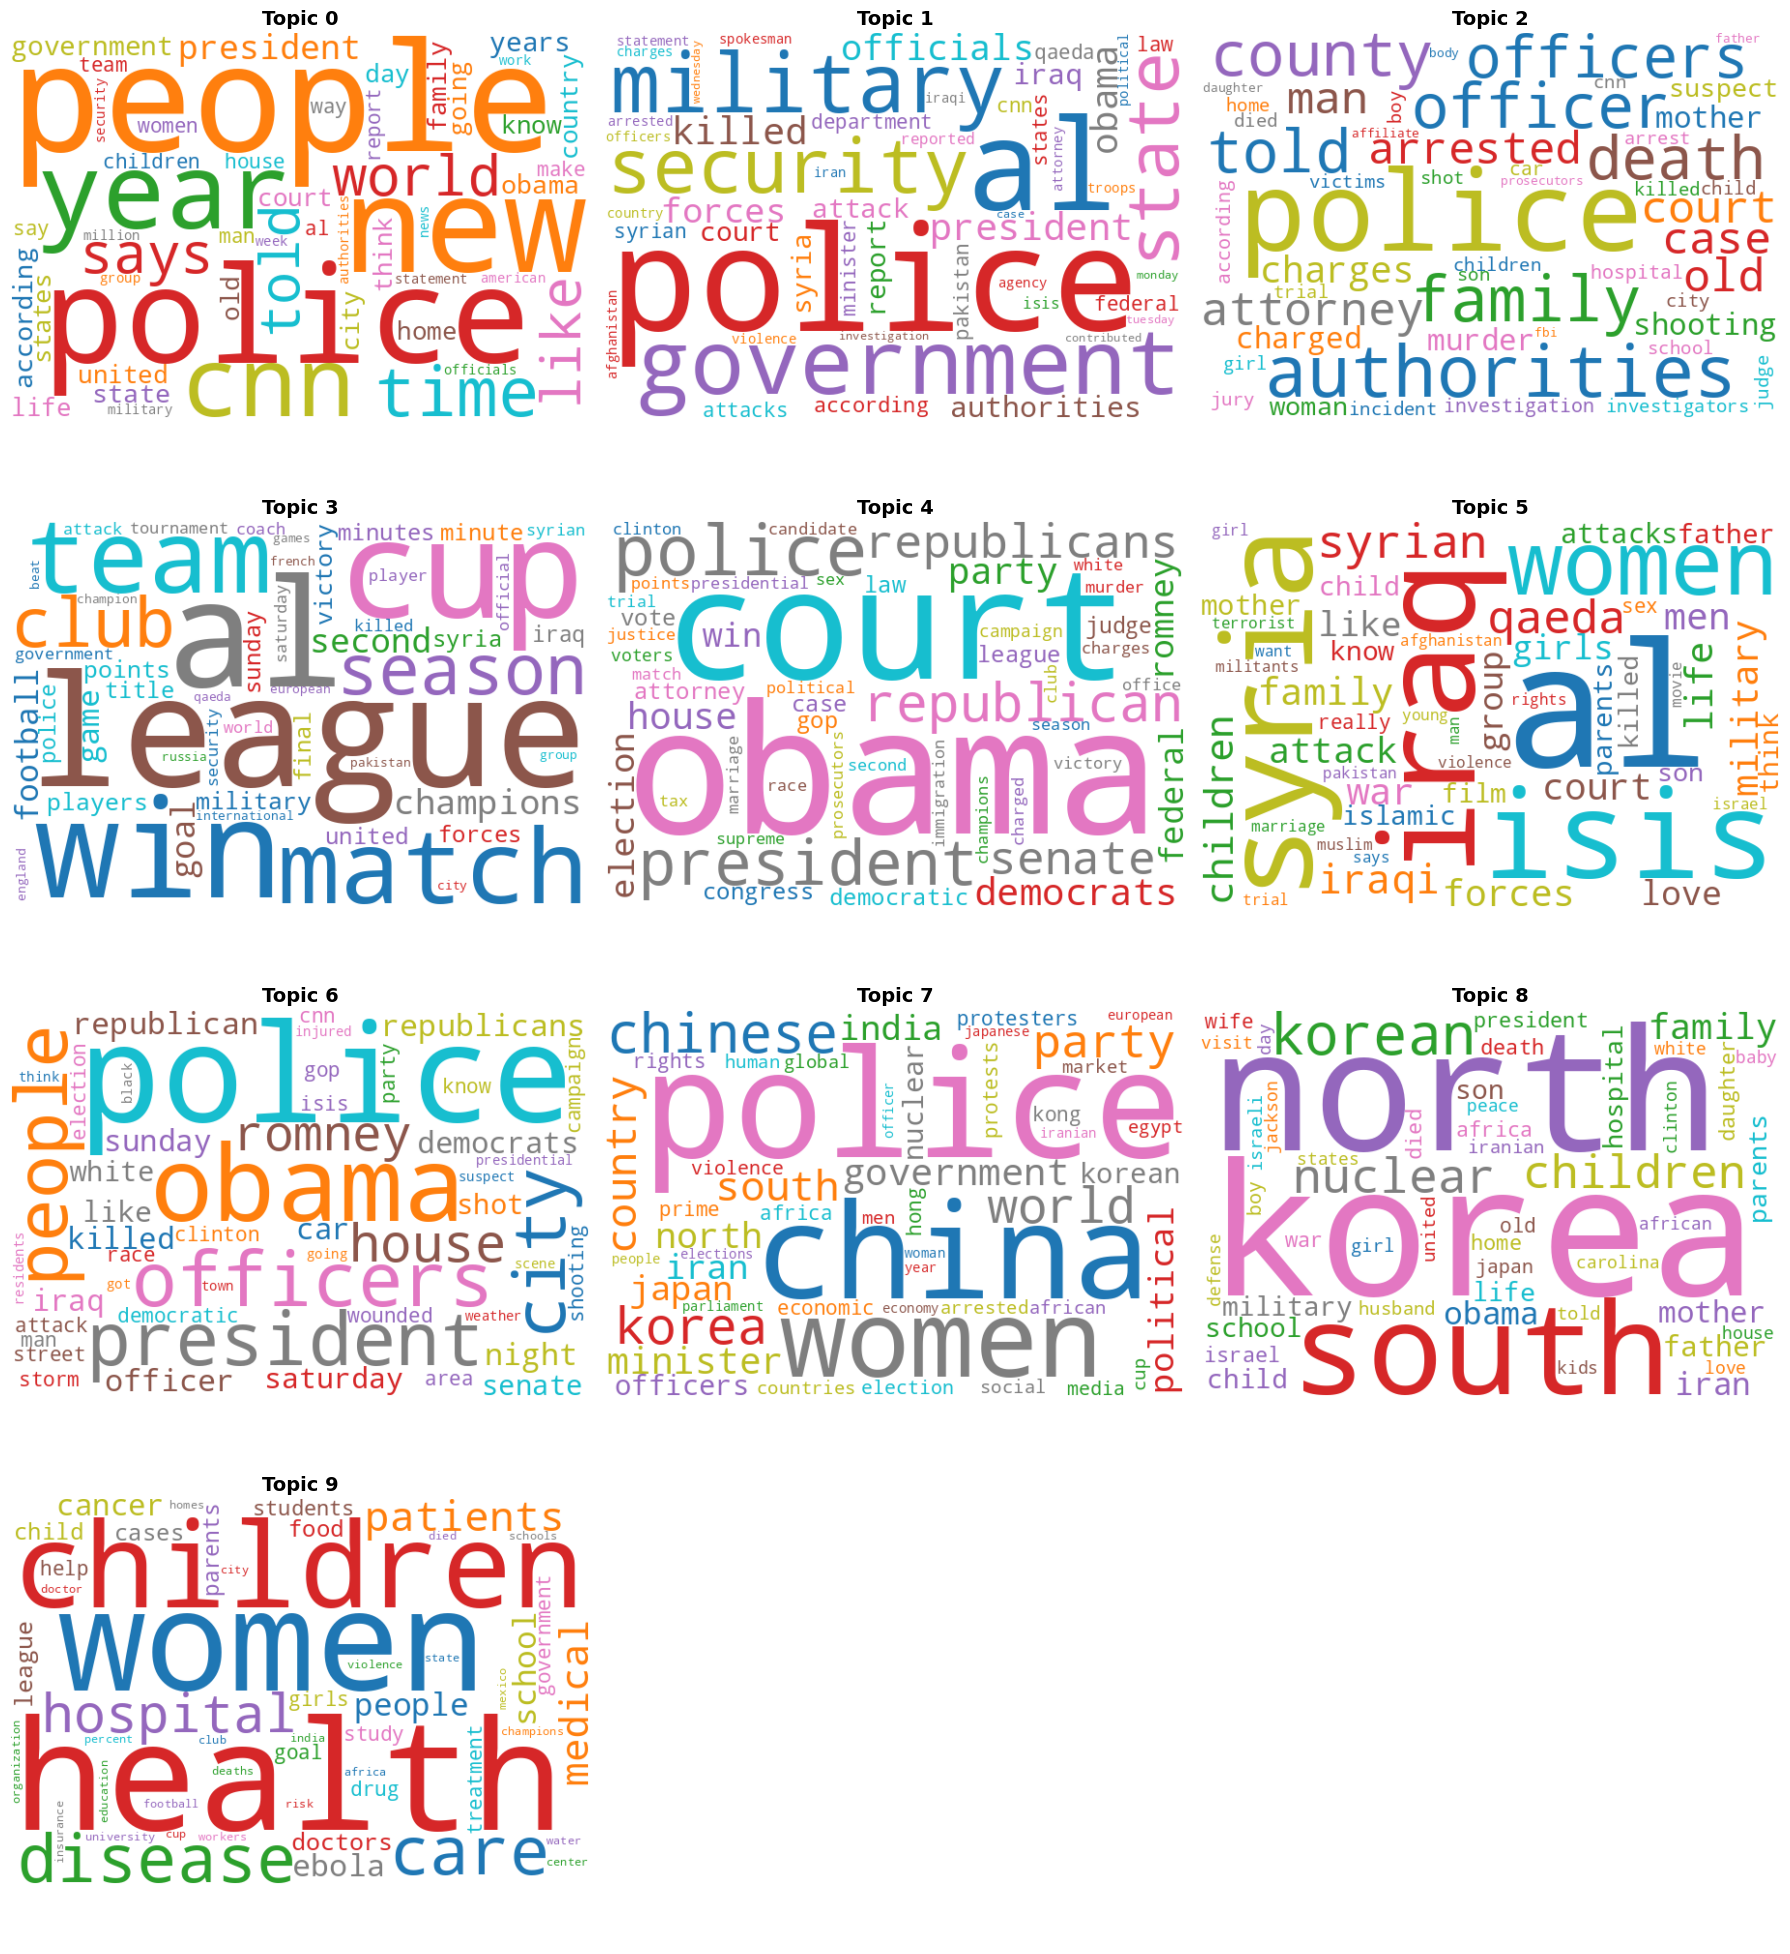

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

terms = vectorizer.get_feature_names_out()

n_topics = len(svd_model.components_)
cols = 3
rows = (n_topics + cols - 1) // cols  # número de filas necesarias

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, comp in enumerate(svd_model.components_):
    # Empareja palabras con pesos y toma las top 50
    terms_comp = zip(terms, comp)
    sorted_terms = sorted(terms_comp, key=lambda x: x[1], reverse=True)[:50]

    # WordCloud espera un dict {palabra: peso} — filtramos pesos negativos
    word_weights = {word: weight for word, weight in sorted_terms if weight > 0}

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='tab10'
    ).generate_from_frequencies(word_weights)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topic {i}', fontsize=14, fontweight='bold')
    axes[i].axis('off')

# Oculta ejes sobrantes si n_topics no es múltiplo de cols
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Evaluación

In [35]:
#@title Implementación coherencia `u_mass`

import math

def get_umass_score(dt_matrix, i, j):
    # Binariza la matriz: 1 si el término aparece en el documento, 0 si no
    zo_matrix = (dt_matrix > 0).astype(int)

    # Extrae la columna del término i y del término j
    col_i, col_j = zo_matrix[:, i], zo_matrix[:, j]

    # Suma ambas columnas: valor 2 indica que ambos términos aparecen en el mismo doc
    col_ij = col_i + col_j
    col_ij = (col_ij == 2).astype(int)  # 1 donde co-ocurren, 0 donde no

    # D(i) = nº de documentos que contienen el término i
    # D(i,j) = nº de documentos que contienen ambos términos a la vez
    Di, Dij = col_i.sum(), col_ij.sum()

    # Fórmula U-Mass: log( (D(i,j) + 1) / D(i) )
    # +1 en el numerador evita log(0) cuando no hay co-ocurrencias
    return math.log((Dij + 1) / Di)


def get_topic_coherence(dt_matrix, topic, n_top_words):
    # Empareja cada peso del tópico con su índice de término
    indexed_topic = zip(topic, range(0, len(topic)))

    # Ordena por peso descendente y toma las n_top_words palabras más relevantes
    topic_top = sorted(indexed_topic, key=lambda x: 1 - x[0])[0:n_top_words]

    coherence = 0
    # Itera sobre todos los pares (i, j) con i < j entre las top words
    for j_index in range(0, len(topic_top)):
        for i_index in range(0, j_index):  # solo pares sin repetir
            i = topic_top[i_index][1]  # índice real del término i en la matriz
            j = topic_top[j_index][1]  # índice real del término j en la matriz

            # Acumula el score U-Mass del par (i, j)
            coherence += get_umass_score(dt_matrix, i, j)
    return coherence


def get_average_topic_coherence(dt_matrix, topics, n_top_words):
    total_coherence = 0

    # Suma la coherencia de cada tópico
    for i in range(0, len(topics)):
        total_coherence += get_topic_coherence(dt_matrix, topics[i], n_top_words)

    # Devuelve el promedio entre todos los tópicos
    return total_coherence / len(topics)

In [36]:
get_average_topic_coherence(X, svd_model.components_, 10)

-65.98176090728279

Veamos dónde tenemos la mayor coherencia

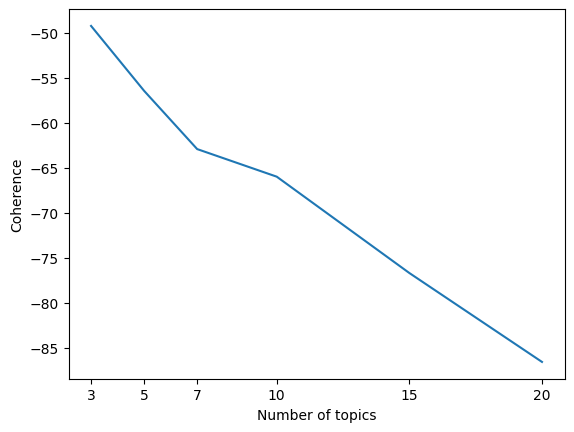

In [37]:
import matplotlib.pyplot as plt

num_topics = [3,5,7,10,15,20]
coherences = []

for k in num_topics:
    svd_model = TruncatedSVD(n_components=k, algorithm='randomized',
                         n_iter=100, random_state=122)
    svd_model.fit(X)
    coherences.append(get_average_topic_coherence(X, svd_model.components_, 10))

plt.figure()
plt.plot(num_topics, coherences)
plt.xlabel('Number of topics')
plt.ylabel('Coherence')
plt.xticks(num_topics)
plt.show()

# [LDA](https://radimrehurek.com/gensim/models/ldamodel.html) con gensim

Para usar la implementación de LDA de gensim necesitamos un diccionario relacionando los índices de las palabras y las palabras. Esta información ya la tenemos con el vectorizador TF-IDF.

El atributo `vocabulary_` de la clase `TfidfVectorizer` es un diccionario de la forma
            
        word: word_index

In [ ]:
vectorizer.vocabulary_

{'children': np.int64(145),
 'war': np.int64(958),
 'afghanistan': np.int64(15),
 'growing': np.int64(374),
 'london': np.int64(518),
 'new': np.int64(599),
 'york': np.int64(998),
 'says': np.int64(780),
 'mark': np.int64(541),
 'senior': np.int64(795),
 'comments': np.int64(171),
 'monday': np.int64(576),
 'current': np.int64(210),
 'program': np.int64(699),
 'say': np.int64(778),
 'daily': np.int64(213),
 'violence': np.int64(948),
 'country': np.int64(195),
 'response': np.int64(748),
 'big': np.int64(80),
 'cities': np.int64(149),
 'actually': np.int64(9),
 'probably': np.int64(694),
 'lives': np.int64(515),
 'safety': np.int64(774),
 'family': np.int64(294),
 'society': np.int64(823),
 'little': np.int64(513),
 'bit': np.int64(83),
 'like': np.int64(508),
 'city': np.int64(151),
 'added': np.int64(10),
 'report': np.int64(740),
 'released': np.int64(735),
 'earlier': np.int64(253),
 'year': np.int64(995),
 'february': np.int64(301),
 'special': np.int64(836),
 'armed': np.int64(4

Para el modelo LDA de gensim necesitamos especificar un diccionario de la forma
            
        word_index: word

In [ ]:
dicc = dict(zip(vectorizer.vocabulary_.values(),vectorizer.vocabulary_.keys()))

Necesitamos también especificar una matriz sparse de scipy.

In [ ]:
from scipy.sparse import csr_matrix

X_csc = csr_matrix(X)

In [ ]:
%%time

from gensim.matutils import Sparse2Corpus

lda_model = models.LdaModel(corpus=Sparse2Corpus(X_csc,documents_columns=False), num_topics=10, id2word=dicc, random_state=1)

CPU times: user 6.1 s, sys: 44.2 ms, total: 6.14 s
Wall time: 6.21 s


In [ ]:
lda_model.get_topics().shape

(10, 1000)

In [ ]:
word_id = 784

word_topics = lda_model.get_term_topics(word_id=word_id,minimum_probability=0)
word_topics = sorted(word_topics,key=lambda x: x[1], reverse=True)
print(f"Word: {dicc[word_id]}")
print(f"Topics: {word_topics}")

Word: schools
Topics: [(9, np.float32(0.0023636613)), (0, np.float32(0.0006199274)), (2, np.float32(0.00057993206)), (7, np.float32(0.00045530705)), (5, np.float32(0.000430451)), (3, np.float32(0.0004212886)), (6, np.float32(0.00039823877)), (8, np.float32(0.00020642845)), (4, np.float32(0.00011617783)), (1, np.float32(7.045103e-05))]


In [ ]:
lda_model.print_topics()

[(0,
  '0.017*"police" + 0.006*"cnn" + 0.006*"authorities" + 0.005*"according" + 0.005*"flight" + 0.005*"plane" + 0.005*"people" + 0.005*"investigation" + 0.005*"told" + 0.005*"hospital"'),
 (1,
  '0.023*"jackson" + 0.010*"chinese" + 0.010*"bank" + 0.009*"japan" + 0.009*"china" + 0.005*"spain" + 0.005*"trial" + 0.005*"court" + 0.005*"million" + 0.005*"michael"'),
 (2,
  '0.007*"family" + 0.007*"police" + 0.006*"told" + 0.005*"cnn" + 0.005*"children" + 0.005*"people" + 0.005*"home" + 0.005*"old" + 0.005*"mother" + 0.004*"county"'),
 (3,
  '0.020*"iran" + 0.015*"israel" + 0.012*"israeli" + 0.011*"oil" + 0.011*"nuclear" + 0.009*"obama" + 0.009*"iranian" + 0.008*"president" + 0.006*"united" + 0.006*"government"'),
 (4,
  '0.019*"al" + 0.018*"iraq" + 0.014*"isis" + 0.012*"military" + 0.011*"afghanistan" + 0.010*"iraqi" + 0.010*"taliban" + 0.009*"qaeda" + 0.008*"forces" + 0.008*"troops"'),
 (5,
  '0.009*"says" + 0.007*"people" + 0.007*"like" + 0.006*"new" + 0.005*"world" + 0.005*"time" + 0.0

Podemos inspeccionar más a detalle un tópico

In [ ]:
lda_model.show_topic(topicid=9, topn=15)

[('court', np.float32(0.014386256)),
 ('women', np.float32(0.008980767)),
 ('sex', np.float32(0.007964358)),
 ('marriage', np.float32(0.007634084)),
 ('cancer', np.float32(0.007454636)),
 ('law', np.float32(0.007369119)),
 ('justice', np.float32(0.006206258)),
 ('drug', np.float32(0.006096323)),
 ('rights', np.float32(0.006043339)),
 ('supreme', np.float32(0.005920811)),
 ('federal', np.float32(0.0054588118)),
 ('drugs', np.float32(0.005368662)),
 ('case', np.float32(0.005321153)),
 ('state', np.float32(0.0050051133)),
 ('states', np.float32(0.004813239))]

In [ ]:
word = 'team'
word_id = vectorizer.vocabulary_[word]

word_topics = lda_model.get_term_topics(word_id=word_id,minimum_probability=0)
word_topics = sorted(word_topics,key=lambda x: x[1], reverse=True)
print(f"Word: {word}")
print(f"Topics: {word_topics}")

Word: team
Topics: [(8, np.float32(0.009059746)), (2, np.float32(0.0011580548)), (1, np.float32(0.0011370541)), (5, np.float32(0.0010542911)), (4, np.float32(0.001016047)), (7, np.float32(0.0008314309)), (6, np.float32(0.0007808053)), (0, np.float32(0.00075747847)), (9, np.float32(0.0006114985)), (3, np.float32(0.00046925517))]


In [ ]:
lda_model.show_topics(num_topics=10, num_words=10, log=False, formatted=True)

[(0,
  '0.017*"police" + 0.006*"cnn" + 0.006*"authorities" + 0.005*"according" + 0.005*"flight" + 0.005*"plane" + 0.005*"people" + 0.005*"investigation" + 0.005*"told" + 0.005*"hospital"'),
 (1,
  '0.023*"jackson" + 0.010*"chinese" + 0.010*"bank" + 0.009*"japan" + 0.009*"china" + 0.005*"spain" + 0.005*"trial" + 0.005*"court" + 0.005*"million" + 0.005*"michael"'),
 (2,
  '0.007*"family" + 0.007*"police" + 0.006*"told" + 0.005*"cnn" + 0.005*"children" + 0.005*"people" + 0.005*"home" + 0.005*"old" + 0.005*"mother" + 0.004*"county"'),
 (3,
  '0.020*"iran" + 0.015*"israel" + 0.012*"israeli" + 0.011*"oil" + 0.011*"nuclear" + 0.009*"obama" + 0.009*"iranian" + 0.008*"president" + 0.006*"united" + 0.006*"government"'),
 (4,
  '0.019*"al" + 0.018*"iraq" + 0.014*"isis" + 0.012*"military" + 0.011*"afghanistan" + 0.010*"iraqi" + 0.010*"taliban" + 0.009*"qaeda" + 0.008*"forces" + 0.008*"troops"'),
 (5,
  '0.009*"says" + 0.007*"people" + 0.007*"like" + 0.006*"new" + 0.005*"world" + 0.005*"time" + 0.0

In [ ]:
from gensim.corpora import Dictionary

dictionary = Dictionary.from_corpus(Sparse2Corpus(X_csc,documents_columns=False), id2word=dicc)
bow = dictionary.doc2bow(tokenized_docs[0])

topics = lda_model.get_document_topics(bow=bow, minimum_probability=None)

print(topics)

[(5, np.float32(0.41448963)), (6, np.float32(0.57690525))]


Veamos los tópicos de todos los documentos

In [ ]:
topics_list = []

for doc in tokenized_docs:
    bow = dictionary.doc2bow(doc)
    topics = lda_model.get_document_topics(bow=bow, minimum_probability=None)
    topics = sorted(topics,key=lambda x: x[1], reverse=True)
    topics_list.append(topics[0])

print(topics_list[:10])

[(6, np.float32(0.57693636)), (5, np.float32(0.9844776)), (6, np.float32(0.5346992)), (9, np.float32(0.9942656)), (6, np.float32(0.6030933)), (6, np.float32(0.9749931)), (8, np.float32(0.98732066)), (0, np.float32(0.44894475)), (8, np.float32(0.9934281)), (0, np.float32(0.4105502))]


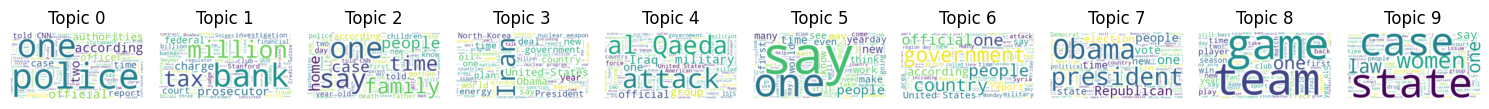

In [ ]:
topics = np.array([x[0] for x in topics_list])
num_topics = len(np.unique(topics))

docs_idxs_per_topic = [np.where(topics == i)[0] for i in range(num_topics)]

fig, axs = plt.subplots(1, num_topics, figsize=(15, 15))
for ax,j in zip(axs.flatten(),range(num_topics)):
    topic_docs = " ".join([docs[i] for i in docs_idxs_per_topic[j]])
    wc = WordCloud(background_color="white", max_words=2000).generate(topic_docs)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Topic {j}")
    ax.axis("off")
fig.tight_layout()
fig.show()

<h3>Evaluación</h3>

La coherencia mide la distancia relativa entre palabras dentro de un tópico. Hay dos tipos principales:
* `c_v` típicamente está en $0 < x < 1$.
* `u_mass` típicamente es negativo.


Valores más altos (menos negativos para `u_mass`) indican mejor coherencia.


La coherencia de un tópico se define como la suma de puntuaciones de similitud por pares sobre el conjunto de palabras $V$ del tópico:

$$
\text{coh}(V) = \sum_{v_i, v_j \in V} \text{score}(v_i, v_j, \epsilon)
$$

donde $\epsilon$ es un factor de suavizado (generalmente $\epsilon = 1$) para evitar $\log(0)$.

* `c_uci` (extrínseca): Los conteos se realizan en un corpus de referencia externo (e.g., Wikipedia). Utiliza la \textbf{Información Mutua Puntual (PMI)}:
    
$$
\text{score}(v_i, v_j, \epsilon) = \log \frac{P(v_i, v_j) + \epsilon}{P(v_i) \cdot P(v_j)}
$$
    
* `u_mass` (intrínseca): Los conteos se realizan en el corpus interno de entrenamiento. La fórmula para un par de palabras $(v_i, v_j)$ es:

$$
\text{score}(v_i, v_j, \epsilon) = \log \frac{D(v_i, v_j) + \epsilon}{D(v_j)}
$$

donde $D(v_i, v_j)$ es el número de documentos que contienen \textbf{ambas} palabras, y $D(v_j)$ es el número de documentos que contienen la palabra $v_j$. La coherencia total del tópico se calcula sumando sobre pares de palabras ordenadas (de la más probable a la menos probable en el tópico).

Referencias: [artículo original coherencia UMASS](https://aclanthology.org/D11-1024.pdf), [artículo comparando UMASS & UCI](https://aclanthology.org/D12-1087.pdf), [discusión en github](https://github.com/piskvorky/gensim/pull/710#issuecomment-425344644), [otra referencia](https://qpleple.com/topic-coherence-to-evaluate-topic-models/).

In [ ]:
cm = CoherenceModel(
    model=lda_model, # Modelo LDA entrenado del que se extraen los tópicos
    coherence='u_mass',
    corpus=Sparse2Corpus(      # Corpus en formato gensim (bag-of-words por documento)
        X_csc,                 #   Matriz sparse en formato CSC (terms × docs o docs × terms)
        documents_columns=False #   False = las columnas son términos, las filas son documentos
    )
    )

coherence = cm.get_coherence()
coherence

np.float64(-1.4997800951929177)

Si queremos usar las estrategias: `c_v`, `c_uci`, `c_npmi` tenemos que proporcionar información del corpus.

In [ ]:
from gensim.corpora import Dictionary

# Reconstruye el diccionario gensim a partir del corpus sparse y el vocabulario existente
dictionary = Dictionary.from_corpus(Sparse2Corpus(X_csc, documents_columns=False), id2word=dicc)

cm = CoherenceModel(
    model=lda_model,          # Modelo LDA entrenado del que se extraen los tópicos
    corpus=Sparse2Corpus(      # Corpus en formato gensim (bag-of-words por documento)
        X_csc,                 #   Matriz sparse en formato CSC (terms × docs o docs × terms)
        documents_columns=False #   False = las columnas son términos, las filas son documentos
    ),
    coherence='c_v',          # Métrica de coherencia: c_v usa ventana deslizante + PMI normalizado (rango 0–1)
    texts=tokenized_docs,     # Lista de documentos tokenizados (palabras crudas), requerido por c_v
    dictionary=dictionary     # Mapeo id↔palabra para traducir índices numéricos a términos
)

coherence = cm.get_coherence()
coherence

/usr/local/lib/python3.12/dist-packages/gensim/topic_coherence/direct_confirmation_measure.py:204: RuntimeWarning: divide by zero encountered in scalar divide
  m_lr_i = np.log(numerator / denominator)
/usr/local/lib/python3.12/dist-packages/gensim/topic_coherence/indirect_confirmation_measure.py:323: RuntimeWarning: invalid value encountered in scalar divide
  return cv1.T.dot(cv2)[0, 0] / (_magnitude(cv1) * _magnitude(cv2))


np.float64(nan)

También podemos ver la coherencia por tópico:

In [ ]:
cm.get_coherence_per_topic()

[np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(0.6851627488032638),
 np.float64(0.4443864333945552)]

Podemos decidir el número de tópicos en función del valor de coherencia

In [ ]:
num_topics = [3+k for k in range(15)]
coherences = []

for k in num_topics:
    lda_model = models.LdaModel(corpus=Sparse2Corpus(X_csc,documents_columns=False),
                                num_topics=k, id2word=dicc, random_state=1,
                                passes=2
                                )
    cm = CoherenceModel(model=lda_model,
                    coherence='u_mass',
                    corpus=Sparse2Corpus(X_csc,documents_columns=False),
                    )
    coherences.append(cm.get_coherence())

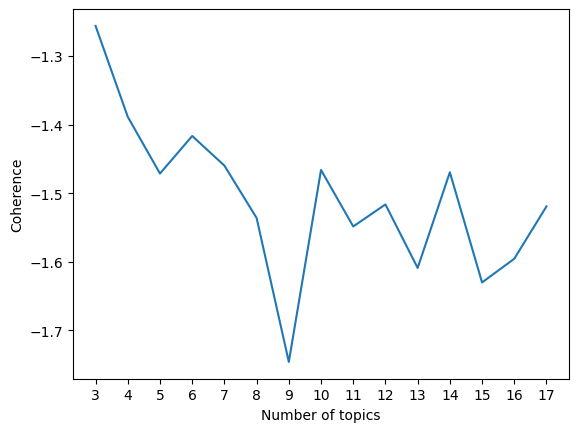

In [ ]:
plt.figure()
plt.plot(num_topics, coherences)
plt.xlabel('Number of topics')
plt.ylabel('Coherence')
plt.xticks(num_topics)
plt.show()

# 🟥 Tarea

## Introducción

Si tenemos un etiquetado ground truth podemos usar métricas que comparan entre agrupamientos. Algunas de estas métricas suelen usarse en tareas de clustering. Algunos ejemplos son:

1. [Rand Index **RI**](https://scikit-learn.org/stable/modules/clustering.html#rand-index)
2. [Mutual Information based scores **MI**](https://scikit-learn.org/stable/modules/clustering.html#mutual-information-based-scores)
3. [Homogeneity, completeness and V-measure **HCV**](https://scikit-learn.org/stable/modules/clustering.html#homogeneity-completeness-and-v-measure)

## Ejercicios

Vamos a realizar la tarea de topic modeling usando el corpus `20newsgroups`

1. Usando LDA obten 20 tópicos, mide el desempeño usando una métrica de cada uno de los 3 grupos descritos anteriormentes (RI, MI, HCV). También mide el desempeño usando la coherencia.
2. Usando LSA obten 20 tópicos, mide el desempeño usando una métrica de cada uno de los 3 grupos descritos anteriormentes (RI, MI, HCV). También mide el desempeño usando la coherencia.
3. Usando un algoritmo de clustering donde se especifique el número de clusters, obtener 20 clusters que, idealmente, representen los tópicos. El algoritmo de clustering lo aplicaras a las representaciones BOW o TF-IDF. Escoge la que mejor desempeño tenga de acuerdo a alguna de las métricas de los 3 grupos anteriores (RI, MI, HCV).
4. En cada una de las 3 estrategias haz una exploración manual de algunos documentos, ¿parece haber coherencia?
5. En cada una de las 3 estrategias haz una nube de palabras por cada tópico, ¿parece haber coherencia en el vocabulario?
---
6. Con el mismo corpus obten el mejor número de tópicos usando LSA de acuerdo a las métricas:
 * Coherencia.
 * Alguna de los grupos RI, MI, HCV.
 * Coherencia usando la similitud coseno entre embeddings.
7. Con el mismo corpus obten el mejor número de tópicos usando LDA de acuerdo a las métricas:
 * Coherencia.
 * Alguna de los grupos RI, MI, HCV.
 * Coherencia usando la similitud coseno entre embeddings.


## Conclusiones

Redacta un pequeño texto respondiendo las siguientes preguntas.

* ¿Cuál método te parece *mejor* en este corpus?
* El hecho de tener las etiquetas reales de tópicos, ¿facilita la tarea?
* ¿Las diferentes métricas parecen ser coherentes entre ellas?